In [1]:
# Loading the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:

# Configuration
DATA_PATH   = '/content/user_data.csv'
BG_COLOR    = 'white'
TEXT_COLOR  = '#263238'
STAGES      = ['homepage', 'product_page', 'cart', 'checkout', 'purchase']
LABELS      = ['Homepage', 'Product Page', 'Cart', 'Checkout', 'Purchase']
COLORS      = ['#1565C0', '#1976D2', '#E53935', '#BA0B08', '#2E7D32']

In [3]:
# Data loading and processing
try:
    df = pd.read_csv(DATA_PATH)
    counts = {s: int((df['stage'] == s).sum()) for s in STAGES}
    vals = [counts[s] for s in STAGES]
    print(f"✅ Data loaded: {len(df):,} lines")
except FileNotFoundError:
    print("❌ Error: File 'user_data.csv' not found. Please specify a valid path to the file")

✅ Data loaded: 17,175 lines


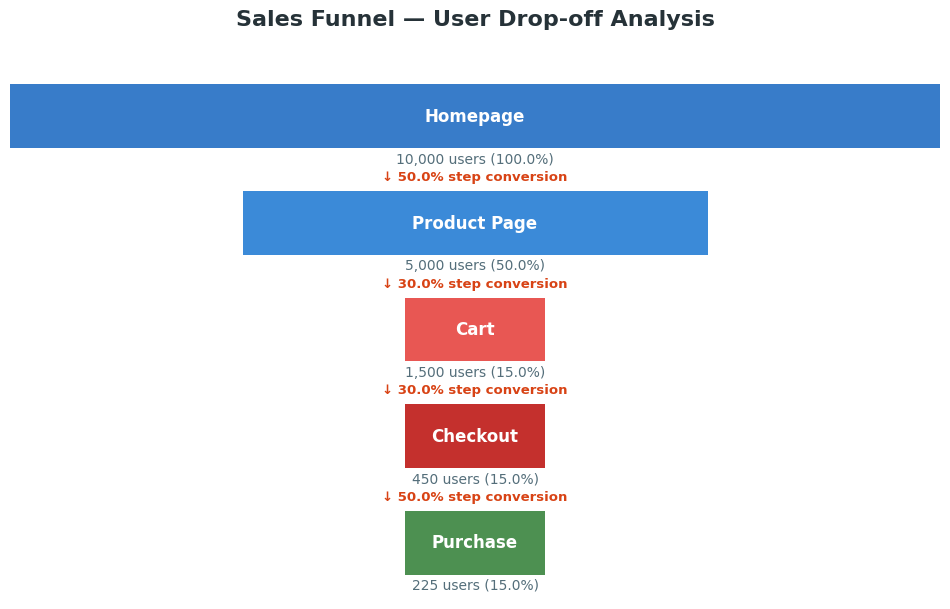

In [4]:

# VISUALIZATION:
# 1: Funnel
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

for i, (label, count, color) in enumerate(zip(LABELS, vals, COLORS)):
    w = count / vals[0] if vals[0] > 0 else 0
    w = max(w, 0.15)
    x = (1.0 - w) / 2
    y = len(STAGES) - i - 1

    # Drawing a bar
    ax.barh(y, w, left=x, height=0.6, color=color, alpha=0.85, zorder=3)

    # Stage text (white on bar background)
    ax.text(0.5, y, label, ha='center', va='center',
            fontsize=12, fontweight='bold', color='white', zorder=4)

    # Number of users below
    ax.text(0.5, y - 0.4, f'{count:,} users ({w*100:.1f}%)',
            ha='center', va='center', fontsize=10, color='#546E7A', zorder=4)

    # Step Conversion
    if i > 0 and vals[i-1] > 0:
        sc = count / vals[i-1] * 100
        ax.text(0.5, y + 0.4, f'↓ {sc:.1f}% step conversion',
                ha='center', fontsize=9.5, color='#D84315', fontweight='bold')

ax.set_xlim(0, 1)
ax.axis('off')
ax.set_title('Sales Funnel — User Drop-off Analysis', fontsize=16, color=TEXT_COLOR, fontweight='bold', pad=25)

plt.savefig('funnel_chart.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show() # We display on the screen

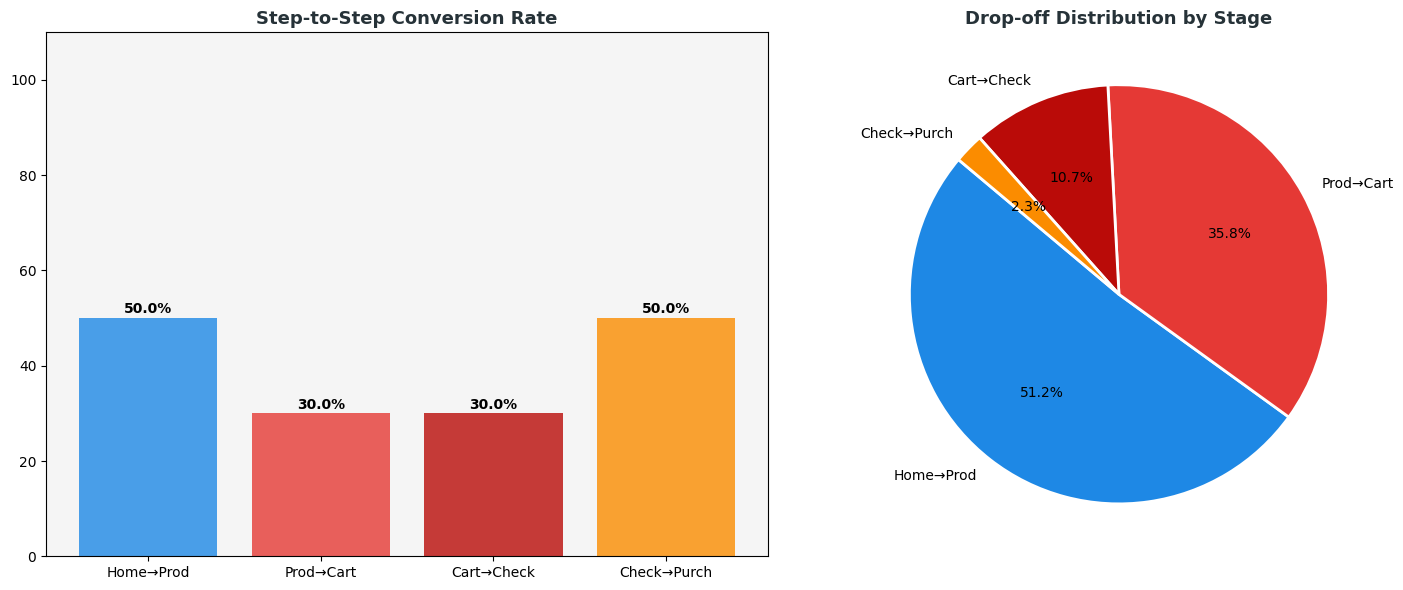

In [5]:
# VISUALIZATION:
# Step Conversion and Exit
step_convs = [round(vals[i] / vals[i-1] * 100, 1) if vals[i-1] > 0 else 0 for i in range(1, len(STAGES))]
transitions = ['Home→Prod', 'Prod→Cart', 'Cart→Check', 'Check→Purch']
dropoffs = [vals[i] - vals[i+1] for i in range(len(STAGES) - 1)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG_COLOR)

# Conversion histogram
axes[0].set_facecolor('#F5F5F5')
bars = axes[0].bar(transitions, step_convs, color=['#1E88E5', '#E53935', '#BA0B08', '#FB8C00'], alpha=0.8)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1, f'{height}%', ha='center', fontweight='bold')

axes[0].set_title('Step-to-Step Conversion Rate', fontsize=13, fontweight='bold', color=TEXT_COLOR)
axes[0].set_ylim(0, max(step_convs + [100]) * 1.1)

# Pie chart of outflow
axes[1].pie(dropoffs, labels=transitions, autopct='%1.1f%%', startangle=140,
            colors=['#1E88E5', '#E53935', '#BA0B08', '#FB8C00'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Drop-off Distribution by Stage', fontsize=13, fontweight='bold', color=TEXT_COLOR)

plt.tight_layout()
plt.savefig('conversion_charts.png', dpi=150, facecolor=BG_COLOR)
plt.show()

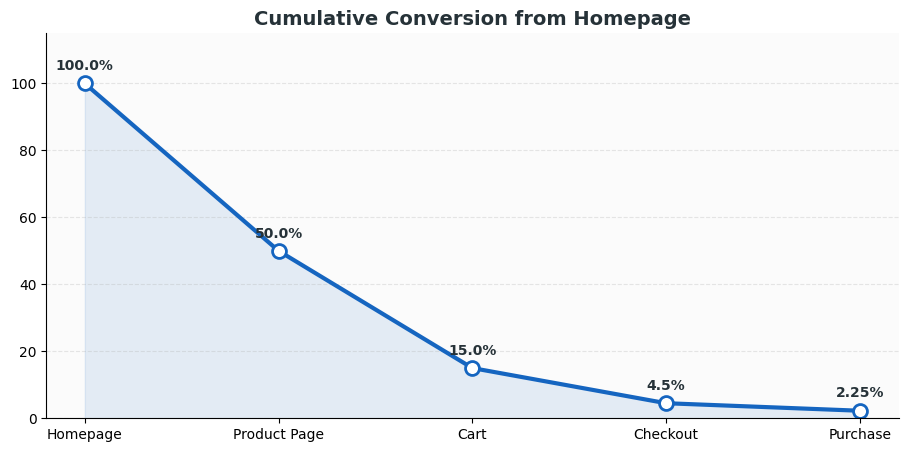

In [6]:
# VISUALIZATION:
# Cumulative conversion
cum_pcts = [round(v / vals[0] * 100, 2) if vals[0] > 0 else 0 for v in vals]
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor('#FBFBFB')

ax.plot(LABELS, cum_pcts, 'o-', color='#1565C0', linewidth=3, markersize=10, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(LABELS, cum_pcts, alpha=0.1, color='#1565C0')

for i, v in enumerate(cum_pcts):
    ax.text(i, v + 4, f'{v}%', ha='center', fontweight='bold', color=TEXT_COLOR)

ax.set_ylim(0, 115)
ax.set_title('Cumulative Conversion from Homepage', fontsize=14, fontweight='bold', color=TEXT_COLOR)
ax.grid(axis='y', linestyle='--', alpha=0.3)
for s in ['top', 'right']: ax.spines[s].set_visible(False)

plt.savefig('cumulative_conversion.png', dpi=150, facecolor=BG_COLOR)
plt.show()